Extracting EDF parameters from ../data/raw/S003R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']
['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4', 'Cp6', 'Fp1', 'Fpz', 'Fp2', 'Af7', 'Af3', 'Afz', 'Af4', 'Af8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'Ft7', 'Ft8', 'T7', 'T8', 'T9', 'T10', 'Tp7', 'Tp8', 'P7'

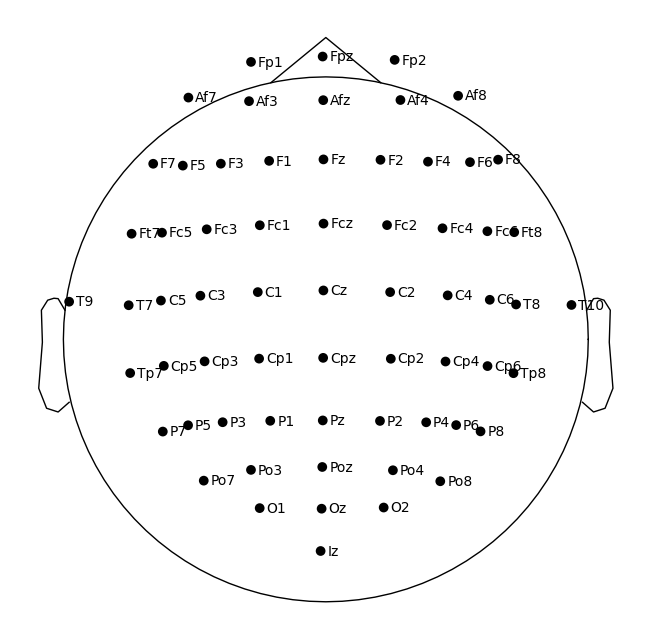

In [67]:
import mne
import matplotlib.pyplot as plt
import numpy as np

pick_sensors=['C3','C4','Cz']
raw = mne.io.read_raw_edf("../data/raw/S003R04.edf", preload=True)

# snapping where channels are located on the scalp to 10*10 
# data is on 1010 but we mne doesnt have 1010 so i am gonna use 1005 which is superset of 1010 and has the same channels as 1010
# channel names in raw instance is different from the channel names in 1005 montage, changing the channel names in raw instance to match montage
print(raw.ch_names)
newNames={ch:ch.replace(".","") for ch in raw.ch_names }
#print(newNames)
raw.rename_channels(newNames)
print(raw.ch_names)

# plotting the channels on the scalp 
raw.set_montage('standard_1005', match_case=False, on_missing='warn')
raw.plot_sensors(show_names=True)
plt.show()



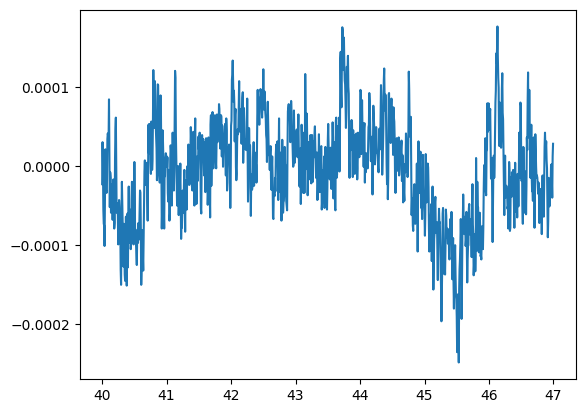

In [107]:
#plotting raw graph (time-domain) along with annotations
t_start,t_end=40,47
s_freq=raw.info["sfreq"]
start_idx,end_idx=int(t_start*s_freq),int(t_end*s_freq)
times= raw.times[start_idx:end_idx]
raw_signal=raw.get_data()[0,start_idx:end_idx]
plt.plot(times,raw_signal)
plt.show()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



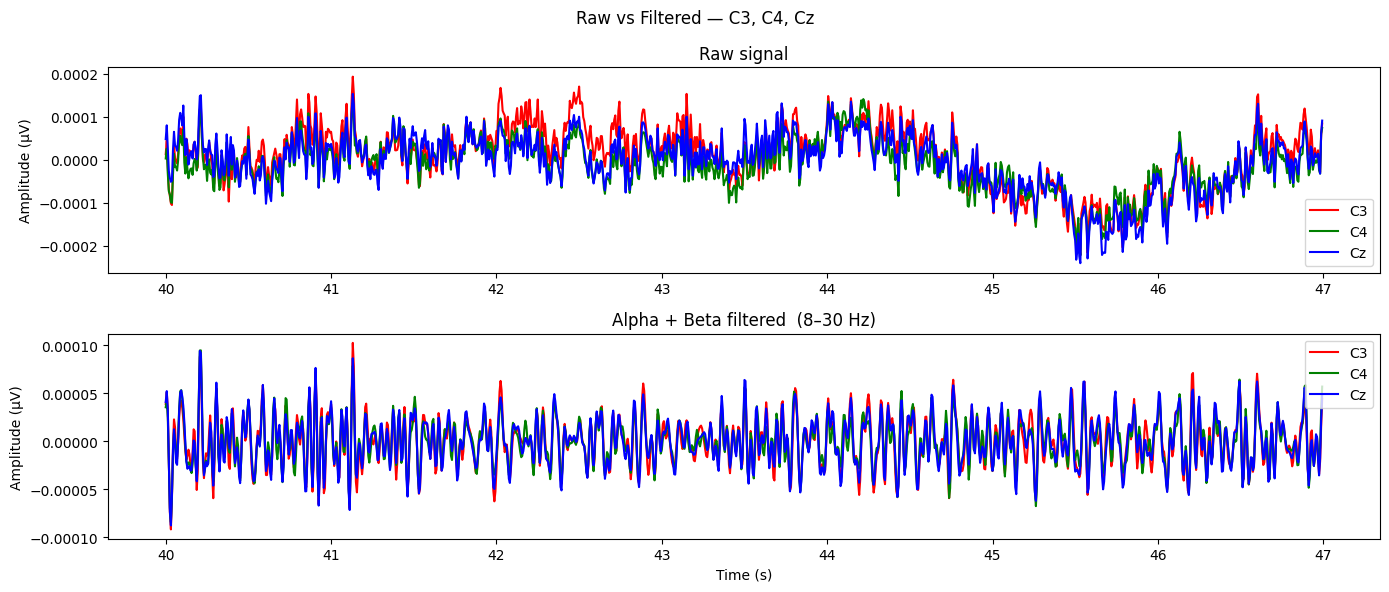

In [ ]:
# Raw vs alpha+beta filtered signal comparison(3 channels C3,C4,Cz) time difference 5 seconds
raw_filtered = raw.copy().filter(8., 30.)   # alpha (8-12 Hz) + beta (13-30 Hz) band

t_start, t_end = 40,47
sfreq = raw.info['sfreq']
start_idx, end_idx = int(t_start * sfreq), int(t_end * sfreq) # to get start_index star_time*sfreq and vice versa 
times = raw.times[start_idx:end_idx]

colors = {'C3': 'r', 'C4': 'g', 'Cz': 'b'}

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

for ch in pick_sensors:
    raw_sig  = raw.get_data(picks=[ch])[0, start_idx:end_idx]
    filt_sig = raw_filtered.get_data(picks=[ch])[0, start_idx:end_idx] 
    axes[0].plot(times, raw_sig,  color=colors[ch],  label=ch)
    axes[1].plot(times, filt_sig, color=colors[ch], label=ch)

axes[0].set_title('Raw signal')
axes[1].set_title('Alpha + Beta filtered  (8–30 Hz)')
for ax in axes:
    ax.set_ylabel('Amplitude (µV)')
    ax.legend()
axes[1].set_xlabel('Time (s)')

fig.suptitle('Raw vs Filtered — C3, C4, Cz')
plt.tight_layout()
plt.show()


Effective window size : 12.800 (s)


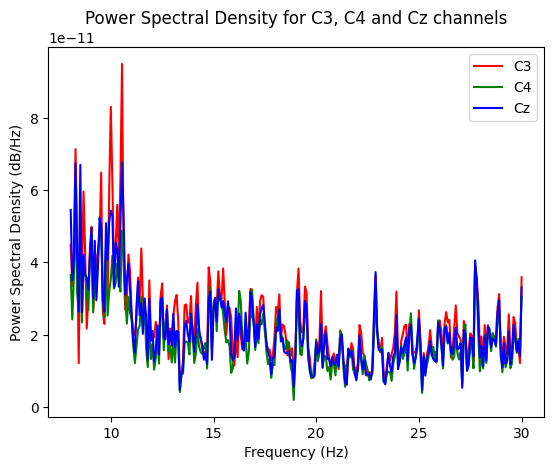

In [90]:
#using psd to visualize the data for different frequency bands
raw_psd=raw.compute_psd(fmin=8,fmax=30,picks=pick_sensors) # max frequency is 30 because we are interested in alpha and beta bands which are between 8-30 Hz
channels=raw_psd.ch_names
power,freqs=raw_psd.get_data(return_freqs=True)
#plot it using matplotlib for each channel with different colors 
colors={'C3':'r','C4':'g','Cz':'b'}
for i,channel in enumerate(channels):
    plt.plot(freqs,power[i],color=colors[channel],label=channel)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (dB/Hz)') 
plt.title('Power Spectral Density for C3, C4 and Cz channels')
plt.legend()
plt.show()    

Effective window size : 12.800 (s)


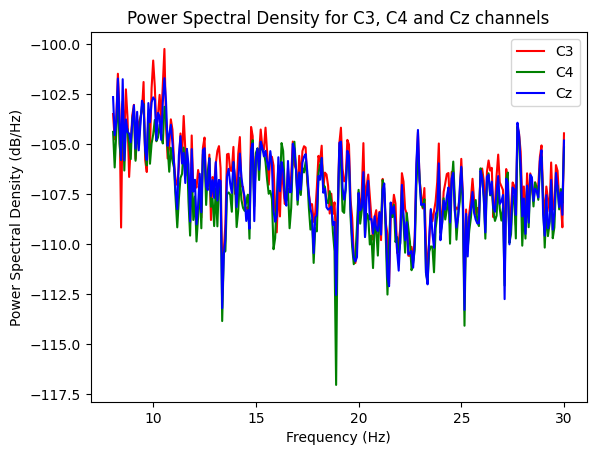

In [ ]:

#using psd to visualize the data for different frequency bands 
#included 
raw_psd=raw.compute_psd(fmin=8, fmax=30,picks=pick_sensors) # max frequency is 30 because we are interested in alpha and beta bands which are between 8-30 Hz
channels=raw_psd.ch_names
power,freqs=raw_psd.get_data(return_freqs=True)
#plot it using matplotlib for each channel with different colors 
colors={'C3':'r','C4':'g','Cz':'b'}
for i,channel in enumerate(channels):
    plt.plot(freqs,10 * np.log10(power[i]),color=colors[channel],label=channel)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (dB/Hz)') 
plt.title('Power Spectral Density for C3, C4 and Cz channels')
plt.legend()
plt.show()

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
<Info | 9 non-empty values
 bads: []
 ch_names: Fc5, Fc3, Fc1, Fcz, Fc2, Fc4, Fc6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
<Epochs | 30 events (good & bad), 0 – 4 s (baseline off), ~31 KiB, data not loaded,
 np.str_('T0'): 15
 np.str_('T1'): 8
 np.str_('T2'): 7>
Using data from preloaded Raw for 15 events and 641 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
(15, 3, 88)
Using data from preloaded Raw for 8 events and 641 original time points ...
0 bad e

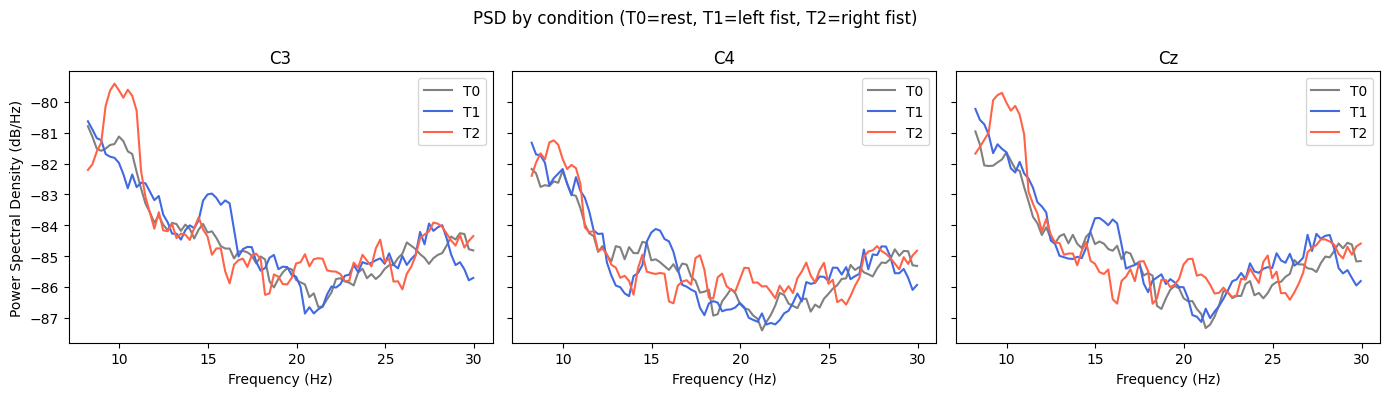

In [117]:
# use annotations on top of psd graph (annotations in time domain -> frequency domain)
# annotations to mne events 
events, eventid = mne.events_from_annotations(raw)
print(eventid)
print(raw.info)
#create epochs for 4 sec window (dataset have 4sec before hitting t0)
epochs = mne.Epochs(
    raw,
    events,
    event_id=eventid,
    tmin=0,
    tmax=4,
    picks=pick_sensors,
    baseline=None
)
print(epochs)
condition_colors = {'T0': 'gray', 'T1': 'royalblue', 'T2': 'tomato'}

# precompute per-condition PSDs
psd_by_cond = {}
for cond_name in eventid:
    psd = epochs[cond_name].compute_psd(fmin=8, fmax=30)
    power, freqs = psd.get_data(return_freqs=True)   # (n_epochs, n_ch, n_freqs)
    print(power.shape)
    psd_by_cond[cond_name] = (psd.ch_names, power.mean(axis=0), freqs)

# one subplot per channel
fig, axes = plt.subplots(1, len(pick_sensors), figsize=(14, 4), sharey=True)

for ax, ch in zip(axes, pick_sensors):
    for cond_name, (ch_names, mean_power, freqs) in psd_by_cond.items():
        ch_idx = ch_names.index(ch)
        ax.plot(freqs, 10 * np.log10(mean_power[ch_idx]),
                color=condition_colors[cond_name], label=cond_name)
    ax.set_title(ch)
    ax.set_xlabel('Frequency (Hz)')
    ax.legend()

axes[0].set_ylabel('Power Spectral Density (dB/Hz)')
fig.suptitle('PSD by condition (T0=rest, T1=left fist, T2=right fist)')
plt.tight_layout()
plt.show()


Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 1121 original time points ...
2 bad epochs dropped
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)


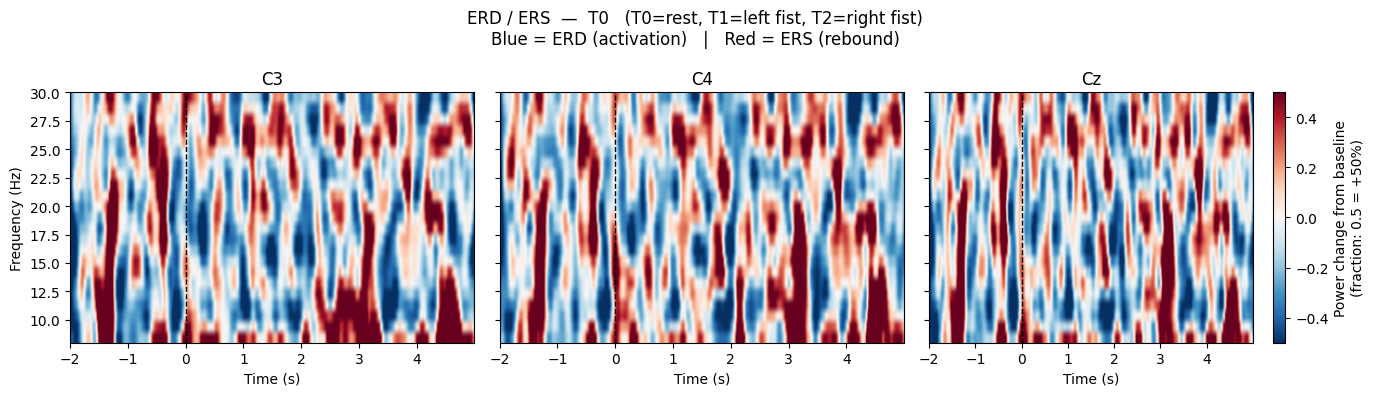

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)


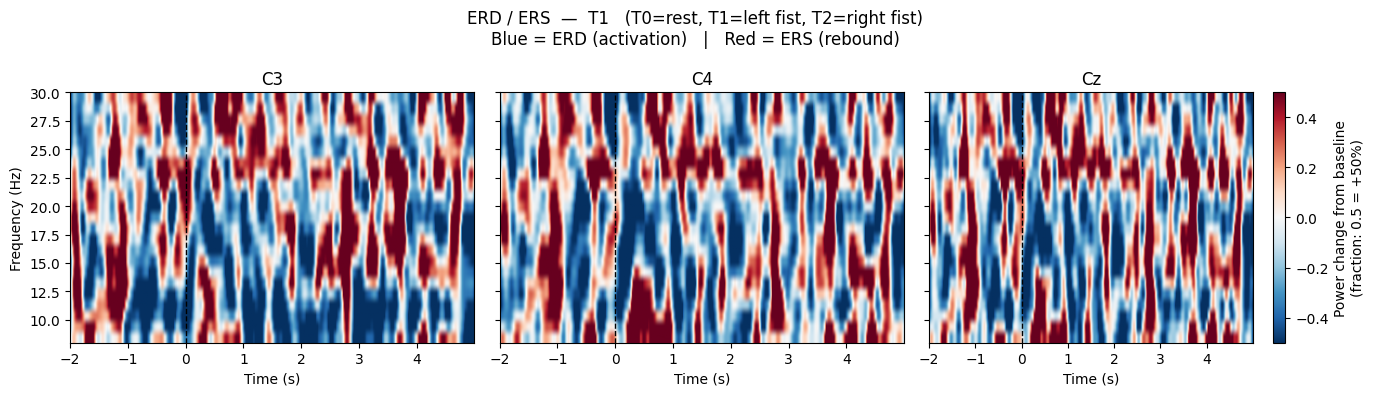

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)


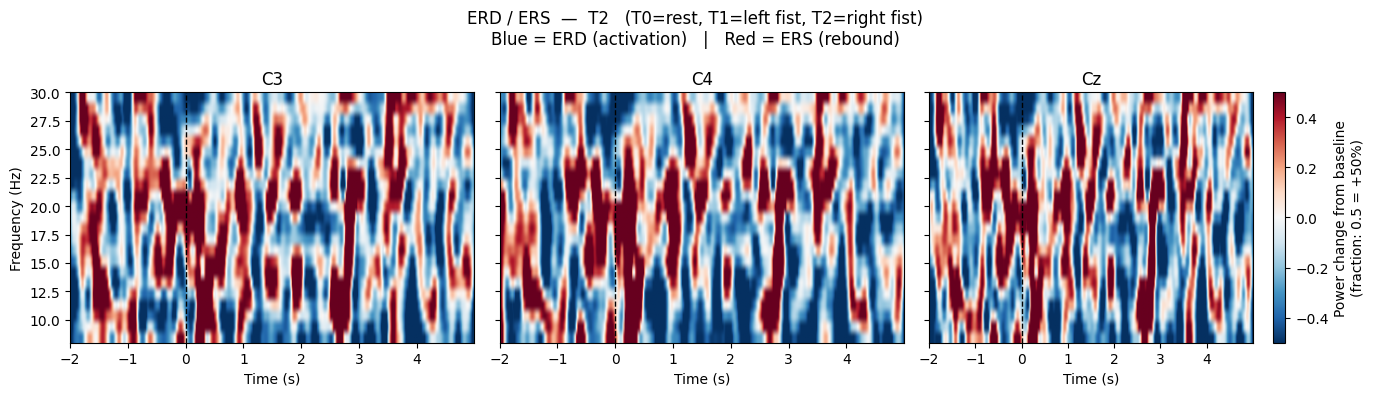

In [93]:
from mne.time_frequency import tfr_morlet

# Epochs with pre-stimulus window so we have a baseline period before event onset
epochs_erds = mne.Epochs(
    raw, events, event_id=eventid,
    tmin=-2, tmax=5,       # -2s baseline before event, 5s after
    picks=pick_sensors,
    baseline=None,         # we apply baseline correction inside TFR below
    preload=True
)

freqs = np.arange(8, 31, 1)   # 8–30 Hz, 1 Hz steps
n_cycles = freqs / 2.0         # wavelet width: higher freq = more cycles

# One figure per condition (T0, T1, T2); columns = channels
for cond_name in eventid:
    tfr = tfr_morlet(
        epochs_erds[cond_name],
        freqs=freqs,
        n_cycles=n_cycles,
        use_fft=True,
        return_itc=False,   # we only want power, not inter-trial coherence
        average=True,
        decim=3             # downsample time axis to keep it fast
    )
    # Baseline: -2s to -0.5s before event (avoids any pre-motor activity at -0.5s)
    # mode='percent': (power - baseline_mean) / baseline_mean
    # negative = ERD (power drop), positive = ERS (power increase)
    tfr.apply_baseline(baseline=(-2, -0.5), mode='percent')

    fig, axes = plt.subplots(1, len(pick_sensors), figsize=(14, 4), sharey=True)
    for ax, ch in zip(axes, pick_sensors):
        ch_idx = tfr.ch_names.index(ch)
        # data shape: (n_channels, n_freqs, n_times)
        im = ax.imshow(
            tfr.data[ch_idx],
            aspect='auto',
            origin='lower',
            extent=[tfr.times[0], tfr.times[-1], freqs[0], freqs[-1]],
            cmap='RdBu_r',   # blue=ERD, red=ERS
            vmin=-0.5, vmax=0.5
        )
        ax.axvline(0, color='k', linestyle='--', linewidth=1, label='event onset')
        ax.set_title(ch)
        ax.set_xlabel('Time (s)')

    axes[0].set_ylabel('Frequency (Hz)')
    fig.colorbar(im, ax=axes[-1], label='Power change from baseline\n(fraction: 0.5 = +50%)')
    fig.suptitle(f'ERD / ERS  —  {cond_name}   (T0=rest, T1=left fist, T2=right fist)\nBlue = ERD (activation)   |   Red = ERS (rebound)')
    plt.tight_layout()
    plt.show()

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 1121 original time points ...
2 bad epochs dropped
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)


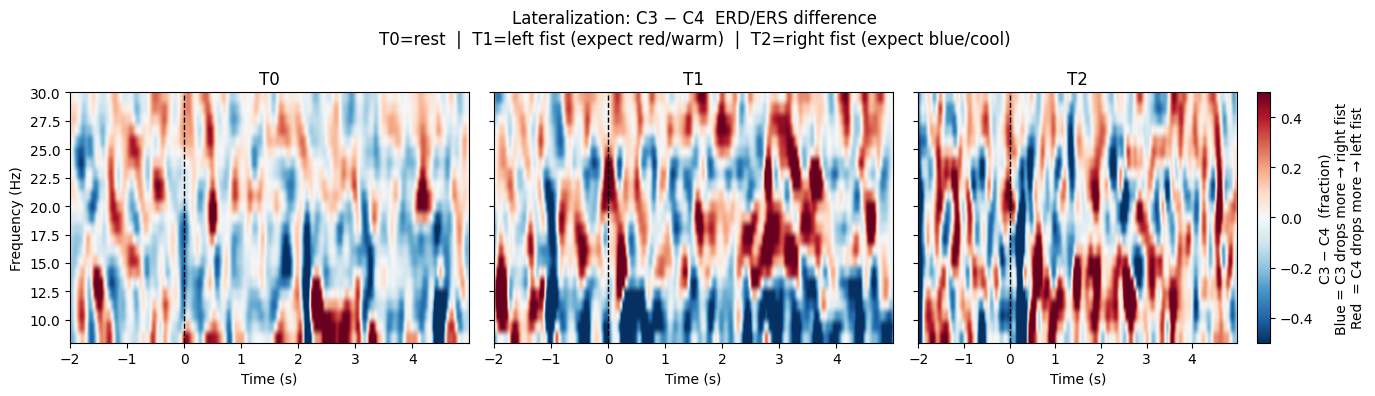

In [73]:
from mne.time_frequency import tfr_morlet

epochs_erds = mne.Epochs(
    raw, events, event_id=eventid,
    tmin=-2, tmax=5,
    picks=pick_sensors,
    baseline=None,
    preload=True
)

freqs = np.arange(8, 31, 1)
n_cycles = freqs / 2.0

# C3 - C4 difference plot per condition
# Blue (negative) = C3 has more ERD  = right fist (T2) activated left motor cortex
# Red  (positive) = C4 has more ERD  = left  fist (T1) activated right motor cortex
fig, axes = plt.subplots(1, len(eventid), figsize=(14, 4), sharey=True)

for ax, cond_name in zip(axes, eventid):
    tfr = tfr_morlet(
        epochs_erds[cond_name],
        freqs=freqs,
        n_cycles=n_cycles,
        use_fft=True,
        return_itc=False,
        average=True,
        decim=3
    )
    tfr.apply_baseline(baseline=(-2, -0.5), mode='percent')

    c3_idx = tfr.ch_names.index('C3')
    c4_idx = tfr.ch_names.index('C4')
    diff = tfr.data[c3_idx] - tfr.data[c4_idx]   # shape: (n_freqs, n_times)

    im = ax.imshow(
        diff,
        aspect='auto',
        origin='lower',
        extent=[tfr.times[0], tfr.times[-1], freqs[0], freqs[-1]],
        cmap='RdBu_r',
        vmin=-0.5, vmax=0.5
    )
    ax.axvline(0, color='k', linestyle='--', linewidth=1, label='event onset')
    ax.set_title(cond_name)
    ax.set_xlabel('Time (s)')

axes[0].set_ylabel('Frequency (Hz)')
fig.colorbar(im, ax=axes[-1], label='C3 − C4  (fraction)\nBlue = C3 drops more → right fist\nRed  = C4 drops more → left fist')
fig.suptitle('Lateralization: C3 − C4  ERD/ERS difference\nT0=rest  |  T1=left fist (expect red/warm)  |  T2=right fist (expect blue/cool)')
plt.tight_layout()
plt.show()